In [ ]:
import os, re, random, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from dataclasses import dataclass
from typing import Dict, List, Union

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 300)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

2025-10-05 16:02:31.639265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759680151.820026      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759680151.870010      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cuda


In [ ]:
path = "/kaggle/input/ag-news-classification-dataset"
train_df = pd.read_csv("/kaggle/input/ag-news-classification-dataset/train.csv")
test_df  = pd.read_csv("/kaggle/input/ag-news-classification-dataset/test.csv")

# Chuẩn hoá tên cột
train_df.columns = [c.lower() for c in train_df.columns]
test_df.columns  = [c.lower() for c in test_df.columns]
display(train_df.iloc[0:5])

,class index,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),"Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday."
4,3,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections."


In [ ]:
def unify(df: pd.DataFrame) -> pd.DataFrame:
    y = df["class index"]
    title = df["title"]
    desc  = df["description"]

    x = (title.astype(str) + " " + desc.astype(str)).str.strip()
    out = pd.DataFrame({"text": x, "raw_label": y})
    return out.dropna().reset_index(drop=True)

train_df = unify(train_df)
test_df  = unify(test_df)

labs = train_df["raw_label"].unique()
labs_sorted = sorted(labs)
mapping = {v:i for i,v in enumerate(labs_sorted)}
train_df["label"] = train_df["raw_label"].map(mapping)
test_df["label"]  = test_df["raw_label"].map(mapping)
num_labels = len(mapping)

tr_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df["label"]
)
print(f"Train: {len(tr_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Classes: {num_labels}")
train_df.head()

Train: 108000 | Val: 12000 | Test: 7600 | Classes: 4


,text,raw_label,label
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",3,2
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",3,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,3,2
3,"Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",3,2
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.",3,2


In [ ]:
# model_name_or_path = "bert-base-uncased"
# model_name_or_path = "distilbert-base-uncased"
model_name_or_path = "prajjwal1/bert-tiny"
# model_name_or_path = "google/bert_uncased_L-2_H-128_A-2"

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

max_len = 256

@dataclass
class ClsDataset(torch.utils.data.Dataset):
    texts: List[str]
    labels: List[int]
    tokenizer: AutoTokenizer
    max_len: int = 256
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            truncation=True,
            max_length=self.max_len,
            return_attention_mask=True,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[i]), dtype=torch.long)
        return item

ds_train = ClsDataset(tr_df["text"].tolist(), tr_df["label"].tolist(), tokenizer, max_len)
ds_val   = ClsDataset(val_df["text"].tolist(), val_df["label"].tolist(), tokenizer, max_len)
ds_test  = ClsDataset(test_df["text"].tolist(), test_df["label"].tolist(), tokenizer, max_len)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name_or_path,
    num_labels=num_labels
).to(device)

id2label = {i: f"class_{i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1m}

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
batch_size = 64
epochs = 3

args = TrainingArguments(
    output_dir="/kaggle/working/agnews-bert",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    logging_steps=50,
    report_to="none",
    optim="adamw_torch",
    lr_scheduler_type="linear",
    warmup_ratio=0.06,
    disable_tqdm=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.483900,0.427859,0.890667,0.890541
2,0.363200,0.331057,0.901750,0.901691
3,0.328500,0.315960,0.903583,0.903482


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=2532, training_loss=0.5234514940029825, metrics={'train_runtime': 110.4767, 'train_samples_per_second': 2932.745, 'train_steps_per_second': 22.919, 'total_flos': 126067476035328.0, 'train_loss': 0.5234514940029825, 'epoch': 3.0})

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Test accuracy: 0.9027631578947368
Test macro-F1: 0.9026084321861292
              precision    recall  f1-score   support

           0     0.9327    0.8895    0.9106      1900
           1     0.9494    0.9784    0.9637      1900
           2     0.8649    0.8558    0.8603      1900
           3     0.8646    0.8874    0.8758      1900

    accuracy                         0.9028      7600
   macro avg     0.9029    0.9028    0.9026      7600
weighted avg     0.9029    0.9028    0.9026      7600



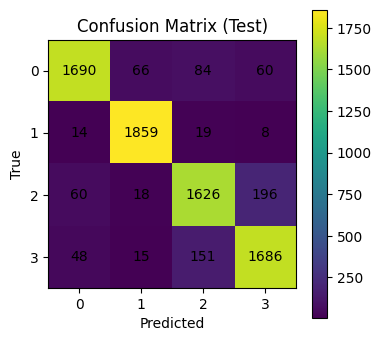

In [ ]:

pred = trainer.predict(ds_test)
logits = pred.predictions
y_pred = logits.argmax(axis=-1)
y_true = np.array(test_df["label"].tolist())

print("Test accuracy:", accuracy_score(y_true, y_pred))
print("Test macro-F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.xticks(range(num_labels), range(num_labels))
plt.yticks(range(num_labels), range(num_labels))
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.colorbar(); plt.show()

In [ ]:
samples = [
    "Apple unveils new iPhone models with upgraded cameras and processors.",
    "The prime minister met with international leaders to discuss climate policy.",
    "The local team secured a dramatic victory in the final seconds.",
    "A new study shows promising results for a cancer treatment.",
]
enc = tokenizer(samples, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**enc).logits
pred_ids = out.argmax(-1).detach().cpu().numpy().tolist()
df_demo = pd.DataFrame({"text": samples, "pred_id": pred_ids})
df_demo

,text,pred_id
0,Apple unveils new iPhone models with upgraded cameras and processors.,3
1,The prime minister met with international leaders to discuss climate policy.,0
2,The local team secured a dramatic victory in the final seconds.,1
3,A new study shows promising results for a cancer treatment.,3


In [ ]:
save_dir = "/kaggle/working/agnews-bert-best"
os.makedirs(save_dir, exist_ok=True)
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved to:", save_dir)

Saved to: /kaggle/working/agnews-bert-best
